<div style="
    background: linear-gradient(90deg, #1e3c72, #c31432);
    padding: 60px 20px;
    margin: 40px auto;
    border-radius: 18px;
    box-shadow: 0 3px 6px rgba(0, 0, 0, 0.3);
    border: 4px solid #ffffff;
    text-align: center;
    width: 95%;
    box-sizing: border-box;
    overflow: visible;
">
    <h1 style="
        color: white !important;
        font-family: 'Arial Black', Arial, sans-serif;
        font-size: 50px;
        font-weight: 900;
        margin: 0 !important;
        padding: 0 !important;
        line-height: 1 !important;
        text-shadow: 2px 2px 5px rgba(0,0,0,0.7);
        display: block;
    ">
        Heart Disease Prediction
    </h1>
</div>



<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
This Kaggle notebook focuses on the Playground Series S6E2 competition.<br>
</div>

![thumbnail](https://images.ctfassets.net/ut7rzv8yehpf/1DhC3uX3EeKnjU02LWyTXH/9c82e6ae82662ed5903eafb40d888d90/8_Main_Types_of_Heart_Disease.jpg?w=1800&h=900&fl=progressive&q=50&fm=jpg)

This competition's dataset is a large synthetic expansion inspired by the classic **UCI Cleveland Heart Disease** dataset. It contains clinical and test-based features commonly used to assess the likelihood of coronary artery disease (CAD). Below is a complete description of each column, including medical context, typical ranges, and why the feature matters in heart disease diagnosis.

| Column Name                  | Description                                                                 | Type          | Typical Range / Values                          | Clinical Relevance / Notes                                                                 |
|------------------------------|-----------------------------------------------------------------------------|---------------|-------------------------------------------------|---------------------------------------------------------------------------------------------|
| 🧓 **Age**                      | Age of the patient in years                                                 | Numeric       | 29–77 (usually 40–70 in heart disease cohorts) | Strong risk factor — risk of CAD increases significantly after age 45 (men) / 55 (women)   |
| 🚹 **Sex**                      | Gender of the patient                                                       | Binary        | 1 = Male<br>0 = Female                          | Men generally have higher risk at younger ages; women’s risk rises post-menopause          |
| 💔 **Chest pain type**          | Type of chest pain experienced                                              | Categorical   | 1 = Typical angina<br>2 = Atypical angina<br>3 = Non-anginal pain<br>4 = Asymptomatic | Most diagnostic power: **Typical angina (1)** and **Asymptomatic (4)** often indicate higher CAD likelihood |
| 💉 **BP**                       | Resting blood pressure (on admission / at rest)                             | Numeric       | 94–200 mm Hg                                    | Hypertension (>140/90) is a major modifiable risk factor for atherosclerosis               |
| 🧈 **Cholesterol**              | Serum cholesterol level                                                     | Numeric       | 126–564 mg/dL                                   | High levels (>200–240 mg/dL) promote plaque buildup in arteries                             |
| 🍬 **FBS over 120**             | Fasting blood sugar > 120 mg/dL (indicator of diabetes suspicion)           | Binary        | 1 = True<br>0 = False                           | Diabetes is a strong CAD risk equivalent — even mild elevations matter                      |
| 📈 **EKG results**              | Resting electrocardiogram (ECG) results                                     | Categorical   | 0 = Normal<br>1 = ST-T wave abnormality<br>2 = Left ventricular hypertrophy | Indicates possible ischemia, strain, or structural changes (e.g., hypertrophy from HTN)    |
| ❤️ **Max HR**                   | Maximum heart rate achieved during exercise                                 | Numeric       | 71–202 bpm                                      | Lower max HR than expected for age can indicate poor cardiac reserve / ischemia            |
| 🏃 **Exercise angina**          | Exercise-induced angina (chest pain during stress test)                     | Binary        | 1 = Yes<br>0 = No                               | Very specific sign of ischemia — reproduction of symptoms during exertion is highly suggestive |
| 📉 **ST depression**            | ST depression induced by exercise relative to rest (mm)                     | Numeric       | 0.0–6.2                                         | Key ECG marker of inducible ischemia — values ≥1.0 mm are often considered diagnostic      |
| ⛰️ **Slope of ST**              | Slope of the peak exercise ST segment                                       | Categorical   | 1 = Upsloping<br>2 = Flat<br>3 = Downsloping    | **Downsloping (3)** is most concerning — indicates more severe ischemia                    |
| 🩸 **Number of vessels fluro**  | Number of major coronary vessels (0–3) colored by fluoroscopy during angiography | Ordinal       | 0, 1, 2, 3                                      | Direct measure of coronary artery disease extent — higher values = more severe CAD         |
| 🧬 **Thallium**                 | Thallium stress test result (myocardial perfusion imaging)                  | Categorical   | Usually 3 = Normal<br>6 = Fixed defect<br>7 = Reversible defect (most common encoding) | Reversible defects indicate ischemia; fixed defects indicate scar  |
| 🎯 **Heart Disease**            | Target variable – diagnosis of heart disease (angiographic disease status)  | Binary        | Presence / Absence                              | **Presence** usually means ≥50% narrowing in at least one major coronary artery           |

### Quick Clinical Context Summary

These features represent a classic combination used since the 1980s in the **UCI Cleveland database**:

- **Demographic / Risk factors** → Age, Sex, Cholesterol, BP, FBS
- **Symptoms** → Chest pain type, Exercise angina
- **Exercise stress test markers** → Max HR, ST depression, Slope of ST
- **Imaging / Anatomic findings** → Number of vessels fluro (from coronary angiography), Thallium (from nuclear perfusion scan)

The most predictive features in most models trained on this dataset family are usually:

1. **Number of vessels fluro** — anatomical severity
2. **Thallium** — functional ischemia/scar assessment
3. **Chest pain type** — symptomatic indicator
4. **Exercise-induced ST changes** (including ST depression, exercise angina, and slope) — ECG evidence of ischemia

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Import Libraries</b></div>

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
banner_palette = [
    "#1e3c72",  # deep blue
    "#3b6cb7",  # blue
    "#5f9ed1",  # soft blue
    "#e57373",  # soft red
    "#c31432"   # deep red
]
sns.set_palette(banner_palette)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_selection import RFECV
import optuna
!pip install optuna-integration[xgboost] -q
from optuna.integration import XGBoostPruningCallback
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 3.5 MB/s eta 0:00:00


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Read and Examine Dataset</b></div>

In [ ]:
df_train = pd.read_csv("Data/train.csv")
df_test = pd.read_csv("Data/test.csv")
print("- The train set's shape is",df_train.shape[0], "rows and", df_train.shape[1], "columns.")
print("- The test set's shape is",df_test.shape[0], "rows and", df_test.shape[1], "columns.")
df_train.head()

- The train set's shape is 630000 rows and 15 columns.
- The test set's shape is 270000 rows and 14 columns.


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [3]:
df_train = df_train.drop("id", axis=1)

In [4]:
TARGET = 'Heart Disease'
numerical_features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]
categorical_features = ["Sex", "Chest pain type", "FBS over 120", "EKG results", 
                        "Exercise angina", "Slope of ST", "Number of vessels fluro",
                       "Thallium"]

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Exploratory Data Analysis</b></div>

## Missing values and duplicates

In [5]:
print(f"======== Train ==========")
print('Missing values count:', df_train.isnull().sum().sum())
print('Duplicate count:', df_train.duplicated().sum(), '\n')

print(f"======== Test ==========")
print('Missing values count:', df_test.isnull().sum().sum())
print('Duplicate count:', df_test.duplicated().sum())

======== Train ==========
Missing values count: 0
Duplicate count: 0 

======== Test ==========
Missing values count: 0
Duplicate count: 0


## Feature Cardinality

In [6]:
print("=== Unique Numeric Data ===")
print(df_train[numerical_features].nunique(),'\n')
print("== Unique Categorical Data ==")
print(df_train[categorical_features].nunique())

=== Unique Numeric Data ===
Age               42
BP                66
Cholesterol      150
Max HR            93
ST depression     66
dtype: int64 

== Unique Categorical Data ==
Sex                        2
Chest pain type            4
FBS over 120               2
EKG results                3
Exercise angina            2
Slope of ST                3
Number of vessels fluro    4
Thallium                   3
dtype: int64


## Univariate EDA

### Target Distribution (Heart Disease)

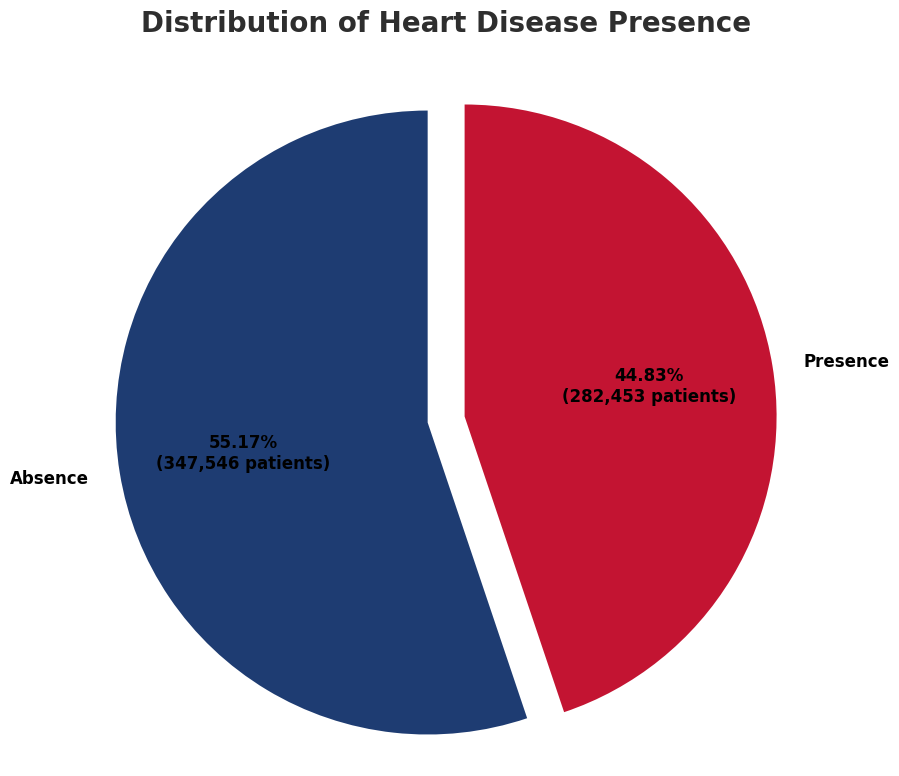

In [7]:
counts = df_train['Heart Disease'].value_counts().sort_index()
labels = ['Absence', 'Presence']
colors = ["#1e3c72", "#c31432"]

plt.figure(figsize=(9, 9))
plt.pie(counts, 
        labels=labels,
        colors=colors,
        autopct=lambda pct: f'{pct:.2f}%\n({int(pct/100*len(df_train)):,} patients)',
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'},
        explode=(0, 0.12))

plt.title('Distribution of Heart Disease Presence', 
          fontsize=20, fontweight='bold', pad=30, color='#2E2E2E')
plt.axis('equal')
plt.show()

### Train-Test Distribution drift

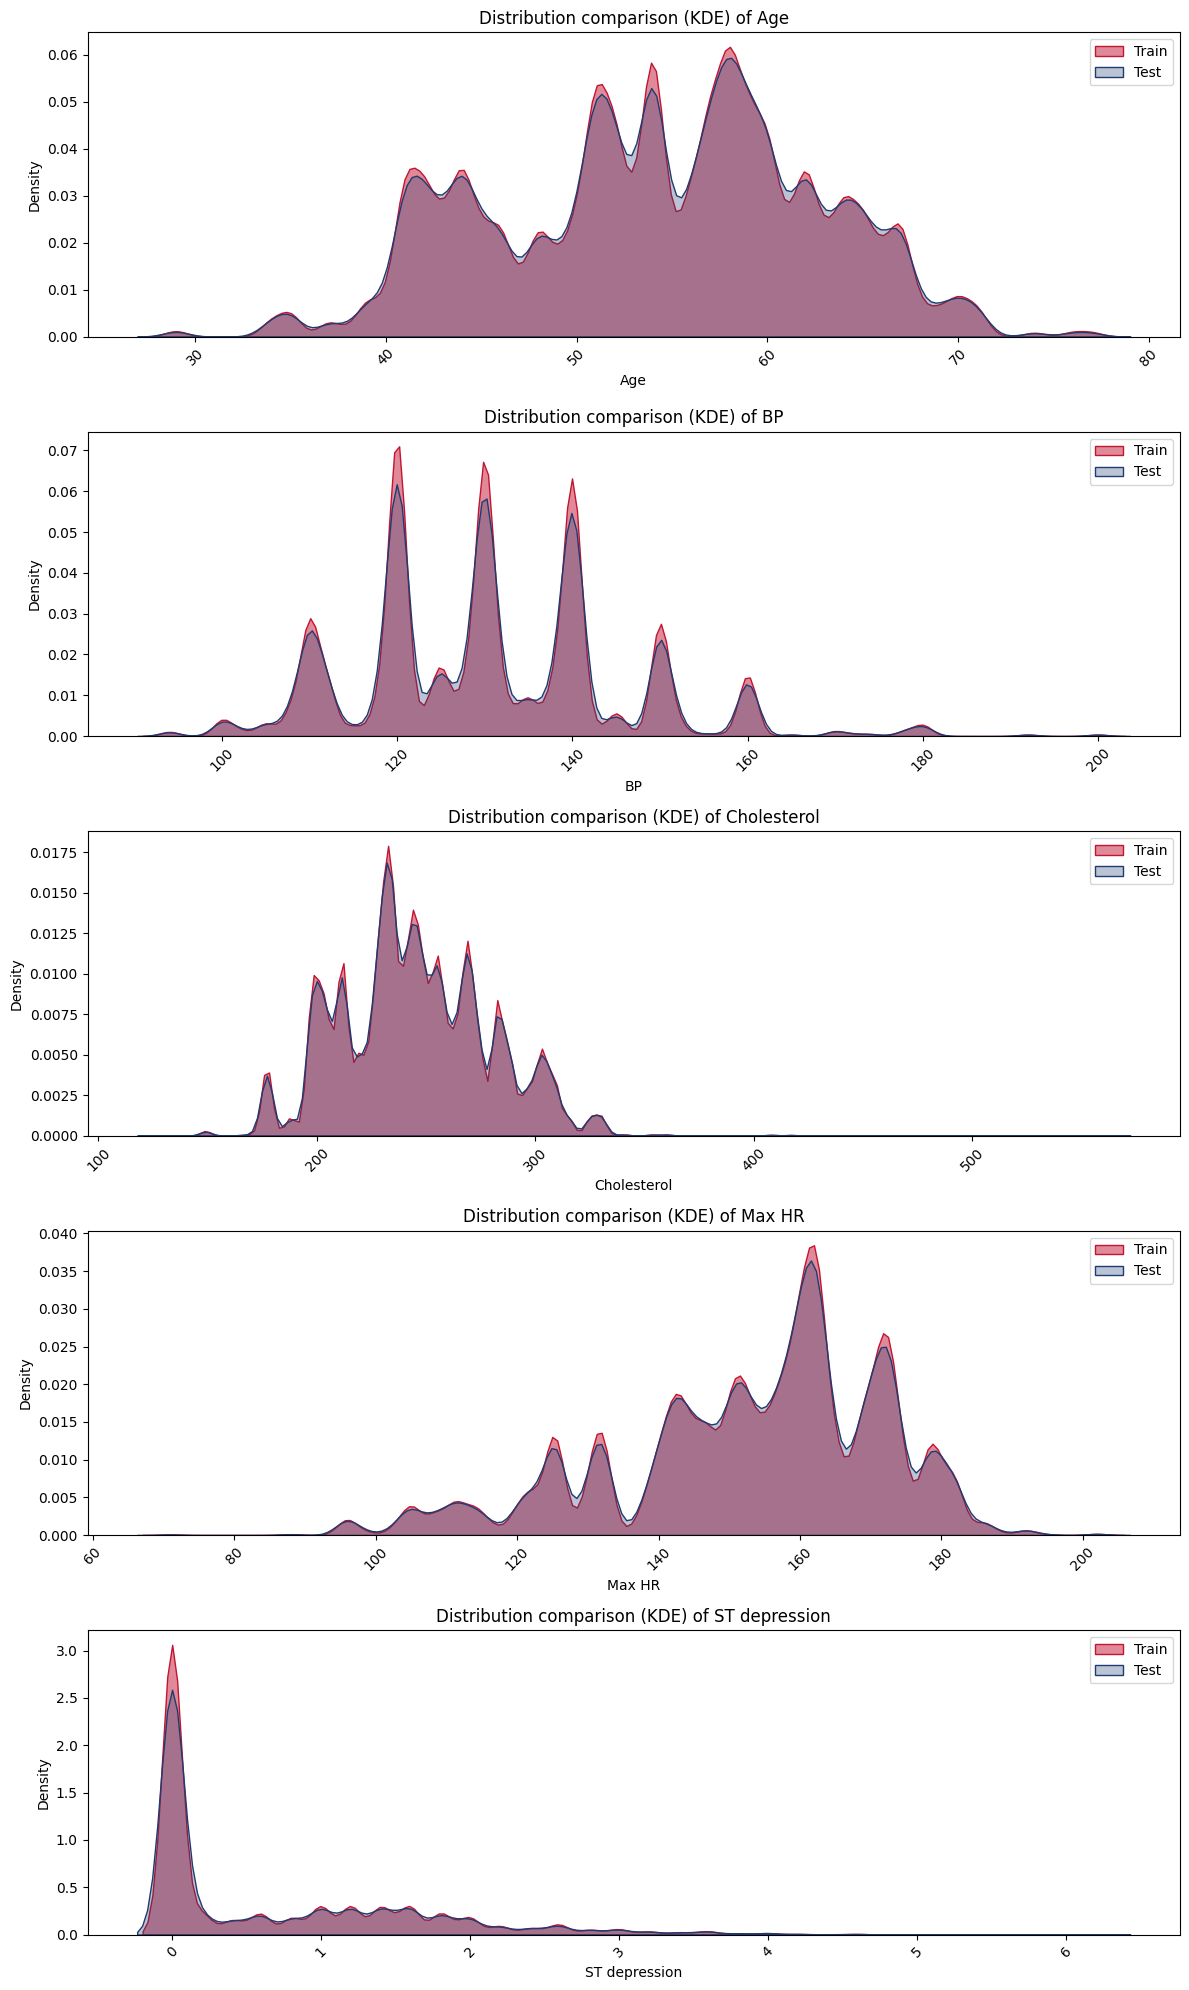

In [16]:
num_features = len(numerical_features)
fig, axes = plt.subplots(num_features, 1, figsize=(12, 4*num_features))

for ax, column in zip(axes, numerical_features):
    sns.kdeplot(df_train[column], ax=ax, label='Train', fill=True, alpha=0.5, color="#c31432")
    sns.kdeplot(df_test[column], ax=ax, label='Test', fill=True, alpha=0.3, color="#1e3c72")
    ax.set_title(f'Distribution comparison (KDE) of {column}')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Distribution of Numerical Features

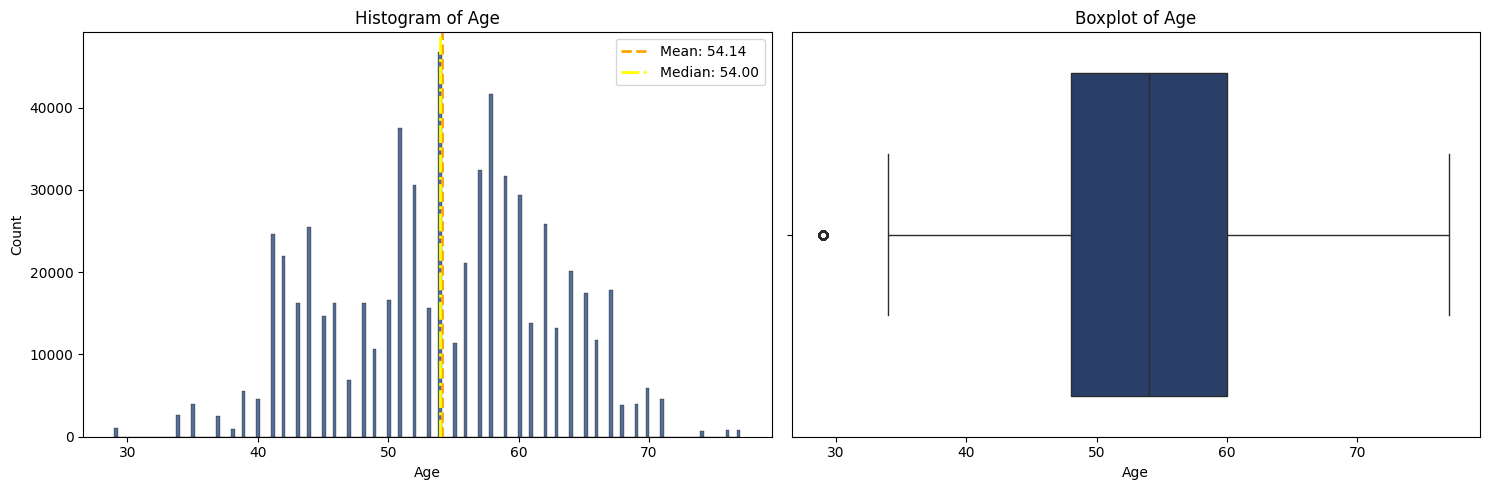

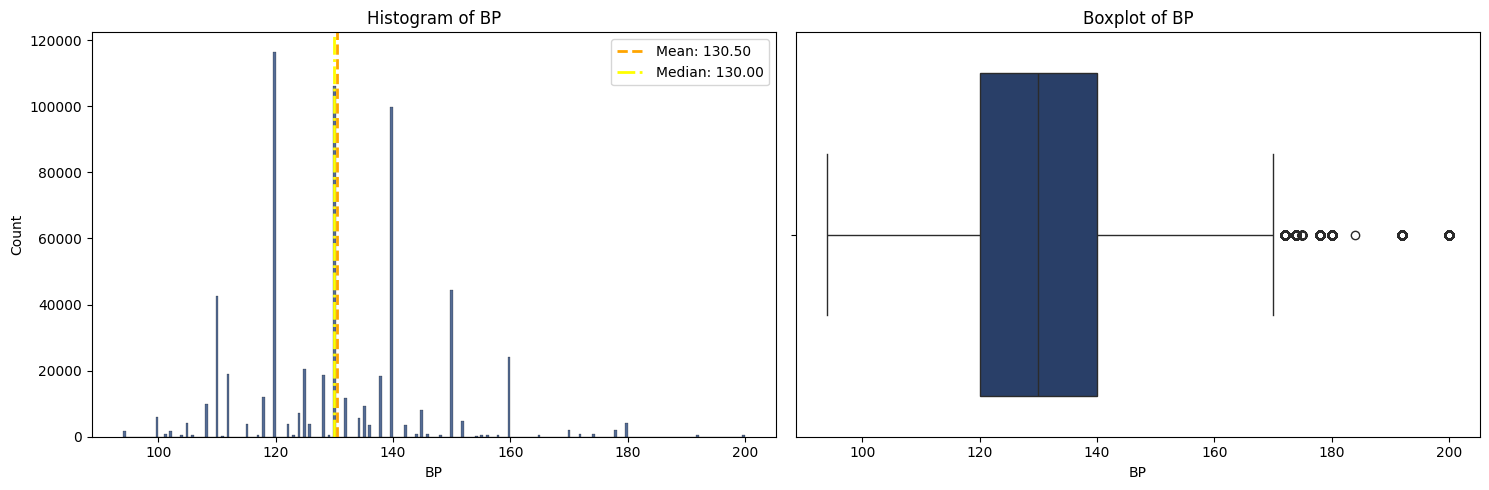

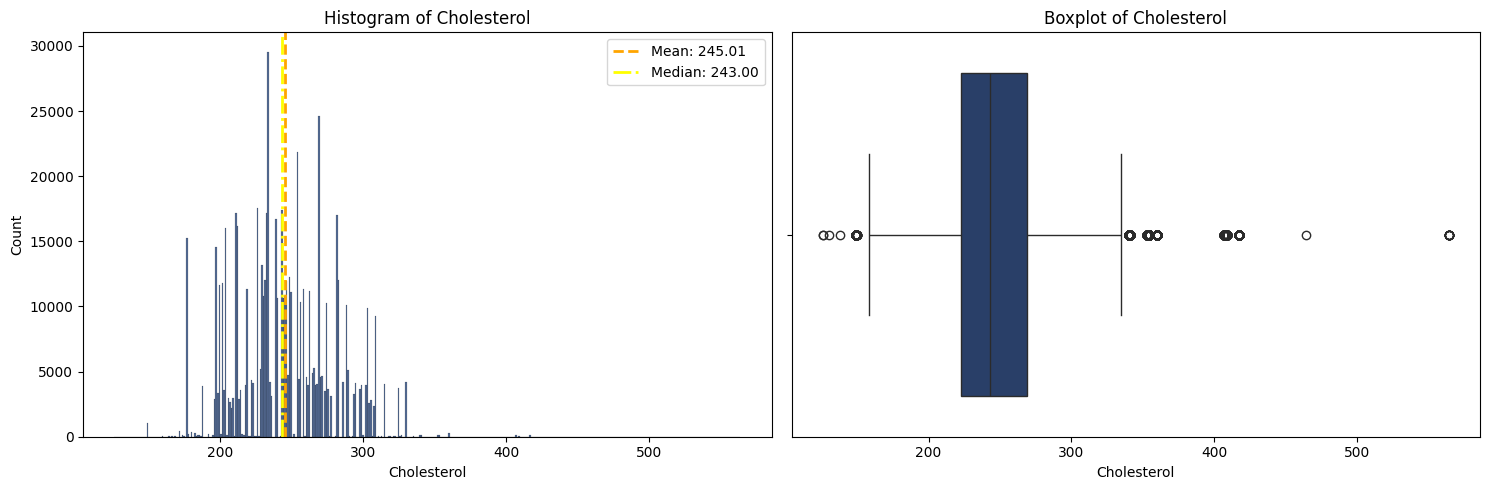

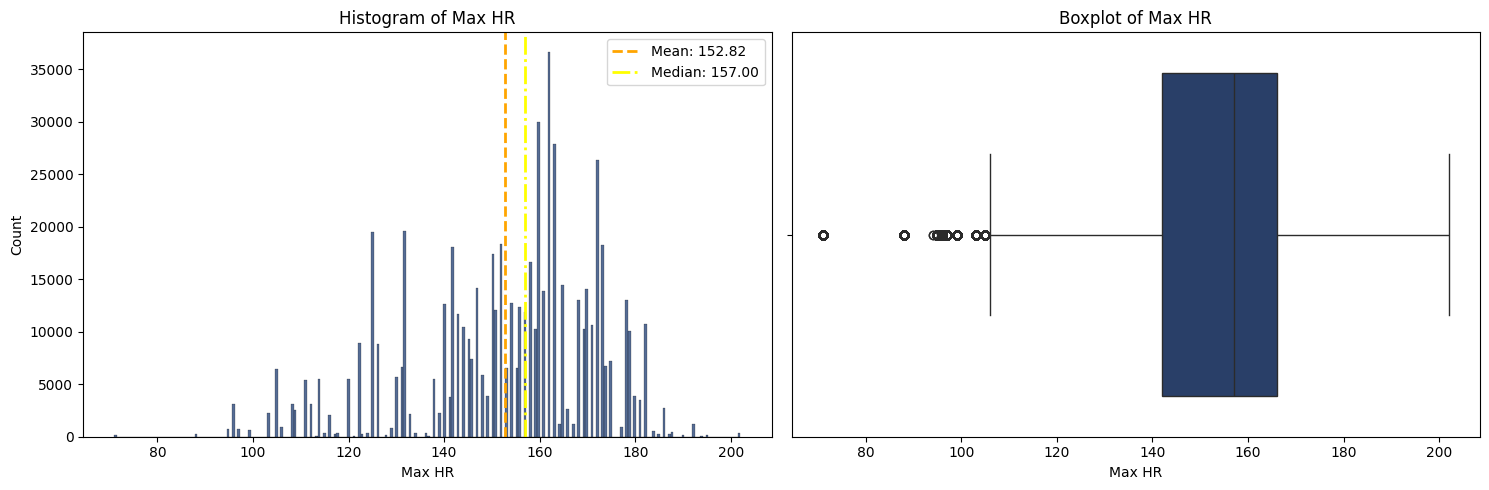

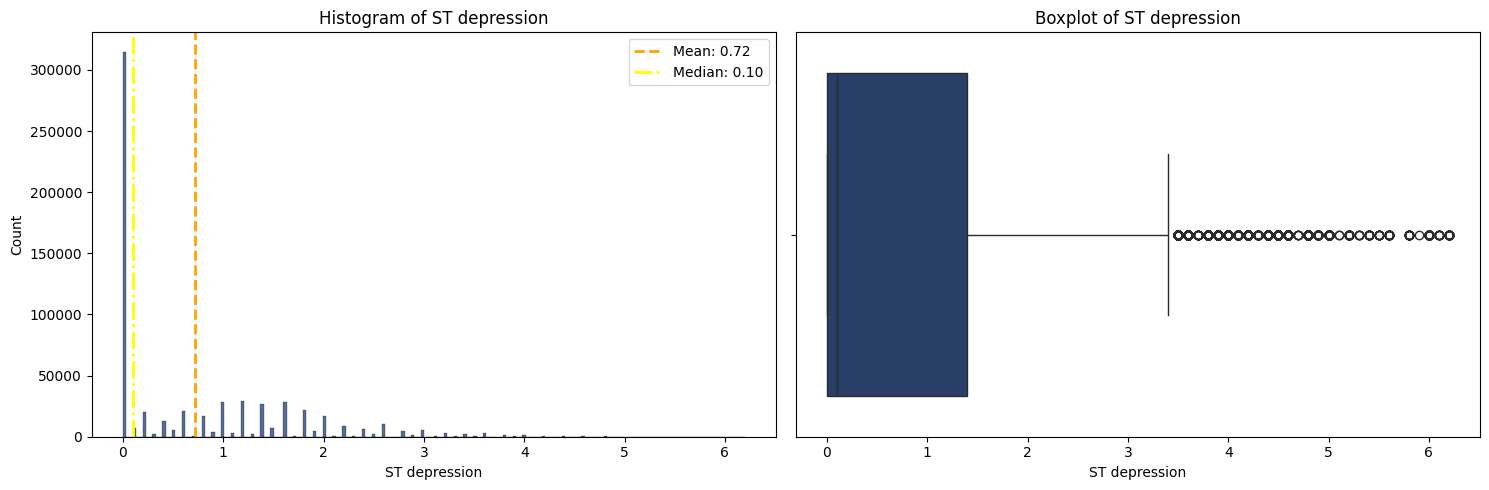

In [9]:
for column in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(data=df_train, x=column, ax=axes[0])
    mean_value = df_train[column].mean()
    median_value = df_train[column].median()
    axes[0].axvline(mean_value, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')
    axes[0].axvline(median_value, color='yellow', linestyle='-.', linewidth=2, label=f'Median: {median_value:.2f}')
    axes[0].set_title(f'Histogram of {column}')
    axes[0].legend()

    sns.boxplot(data=df_train, x=column, ax=axes[1])
    axes[1].set_title(f'Boxplot of {column}')

    plt.tight_layout()
plt.show()

### Skewed Features

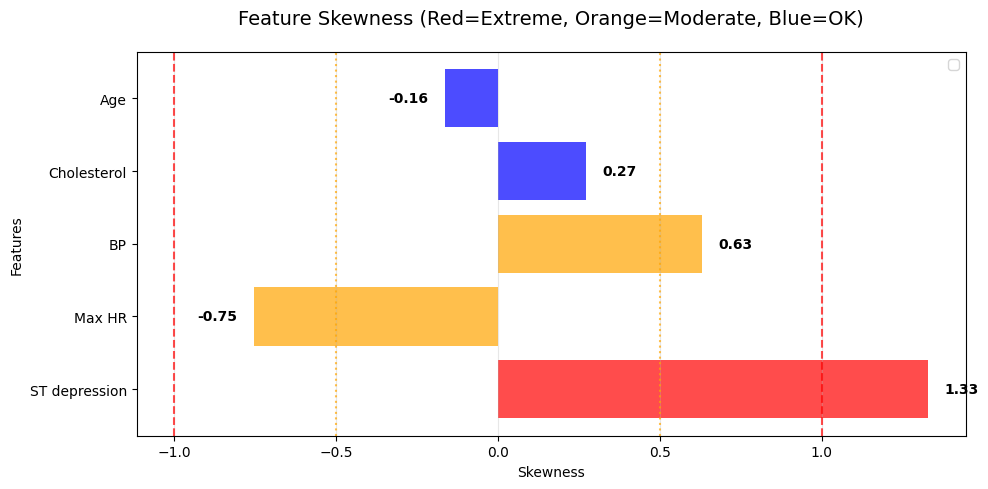

In [11]:
skew_features = df_train[numerical_features].skew().sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['red' if abs(x) > 1 else 'orange' if abs(x) > 0.5 else 'blue' for x in skew_features.values]

bars = plt.barh(skew_features.index, skew_features.values, color=colors, alpha=0.7)

for i, (bar, val) in enumerate(zip(bars, skew_features.values)):
    plt.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2, 
             f'{val:.2f}', ha='left' if val >= 0 else 'right', va='center', fontweight='bold')

plt.title('Feature Skewness (Red=Extreme, Orange=Moderate, Blue=OK)', fontsize=14, pad=20)
plt.xlabel('Skewness')
plt.ylabel('Features')
plt.axvline(x=1, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=-1, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=0.5, color='orange', linestyle=':', alpha=0.7)
plt.axvline(x=-0.5, color='orange', linestyle=':', alpha=0.7)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Distribution of Categorical Features

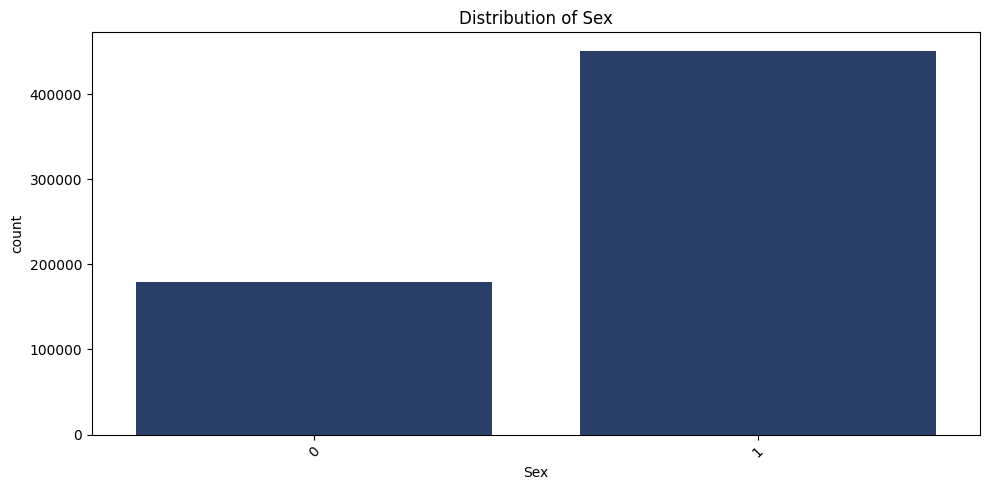

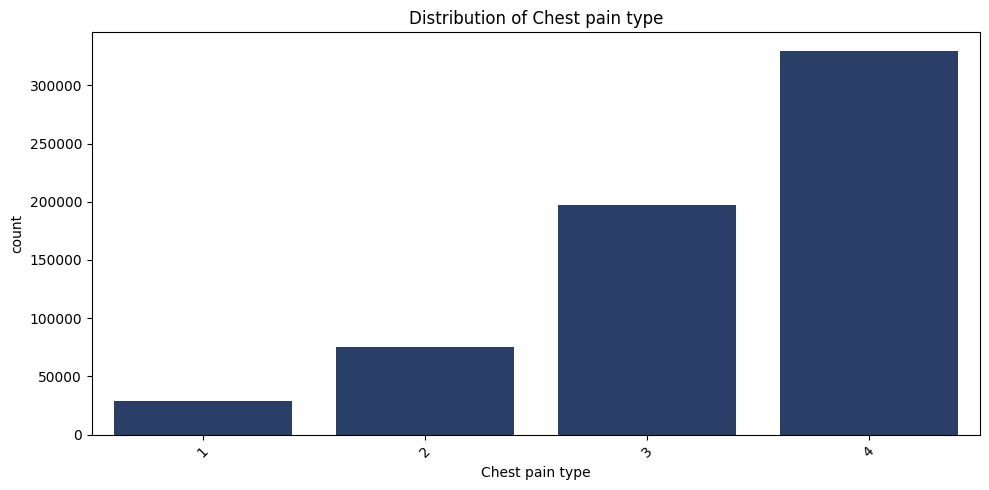

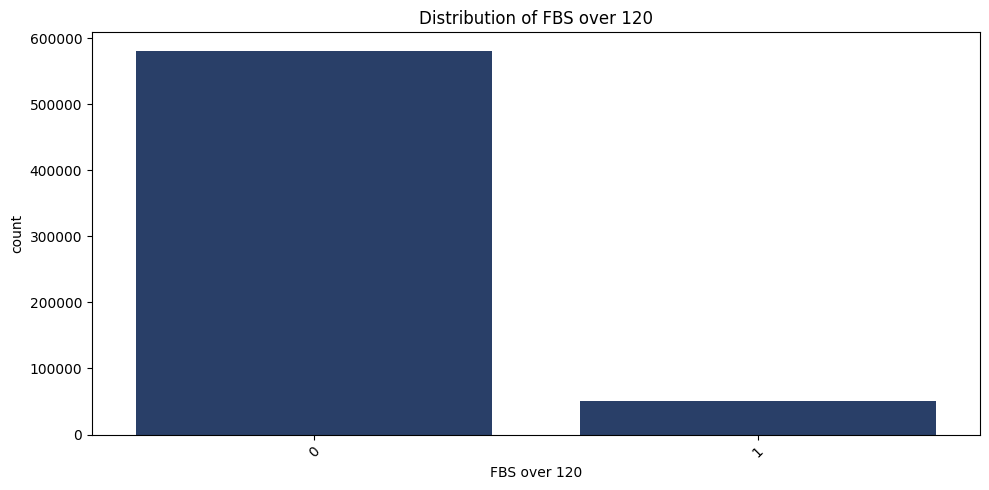

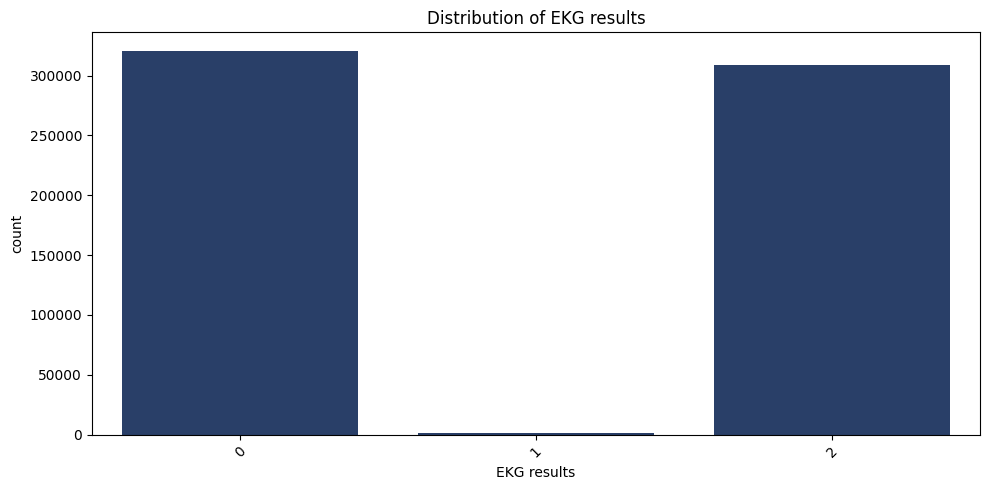

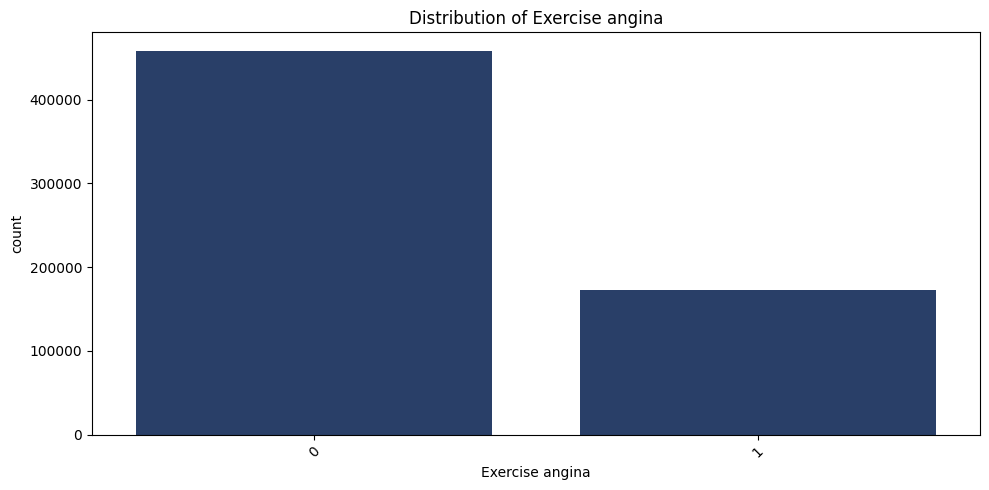

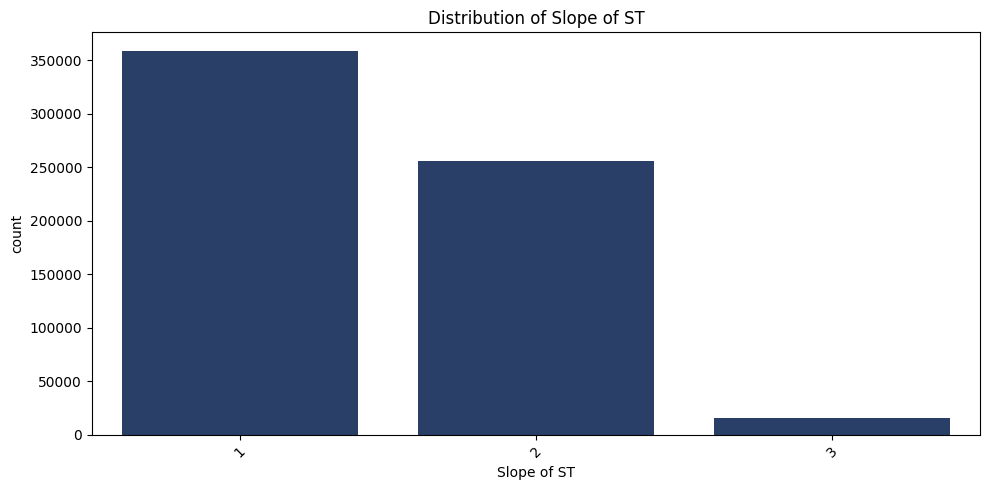

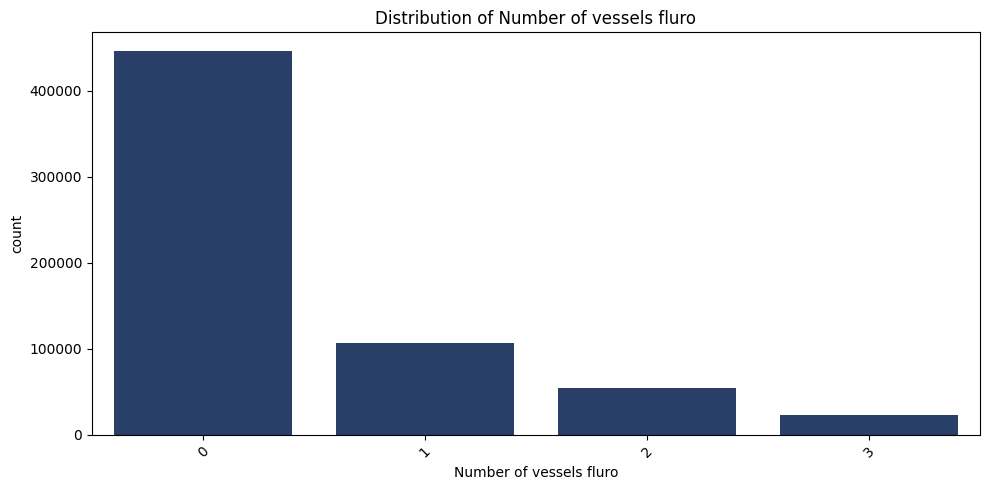

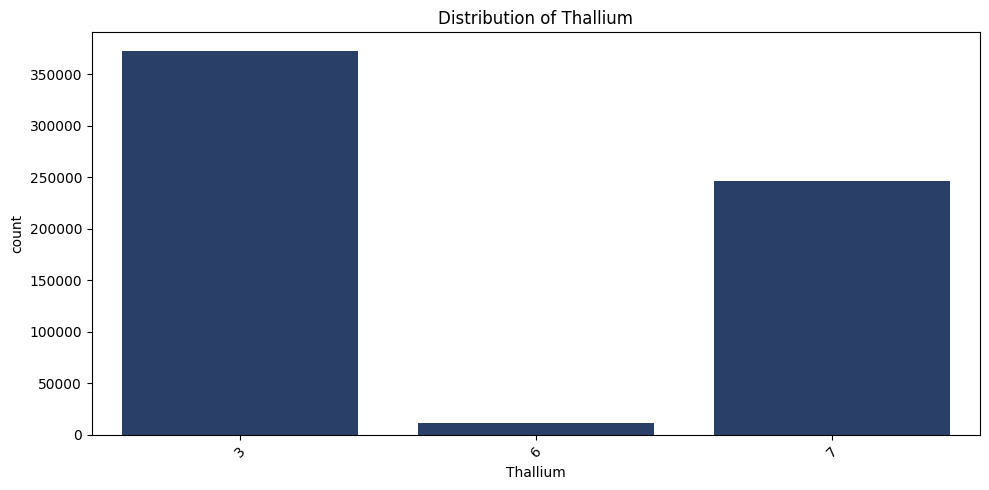

In [12]:
for column in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_train, x=column)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Outlier Analysis

In [13]:
for col in numerical_features:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"{col}: Lower bound = {lower_bound:.2f}, Upper bound = {upper_bound:.2f}")

    outliers = df_train[(df_train[col] < lower_bound) | (df_train[col] > upper_bound)]
    print(f"Number of outliers in {col}: {outliers.shape[0]}\n")

Age: Lower bound = 30.00, Upper bound = 78.00
Number of outliers in Age: 1048

BP: Lower bound = 90.00, Upper bound = 170.00
Number of outliers in BP: 9011

Cholesterol: Lower bound = 154.00, Upper bound = 338.00
Number of outliers in Cholesterol: 2194

Max HR: Lower bound = 106.00, Upper bound = 202.00
Number of outliers in Max HR: 14246

ST depression: Lower bound = -2.10, Upper bound = 3.50
Number of outliers in ST depression: 9971



## Multivariate EDA

### Linear Features Correlation Matrix

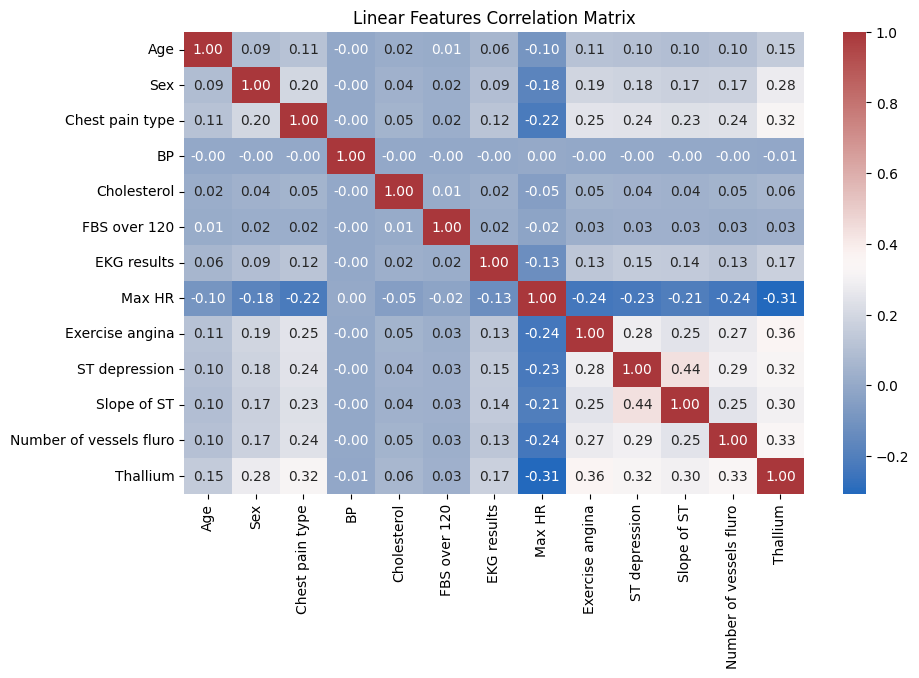

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_train.corr(numeric_only=True), annot=True,fmt='.2f', cmap="vlag")
plt.title("Linear Features Correlation Matrix")
plt.show()

### How Numerical Features affect Target

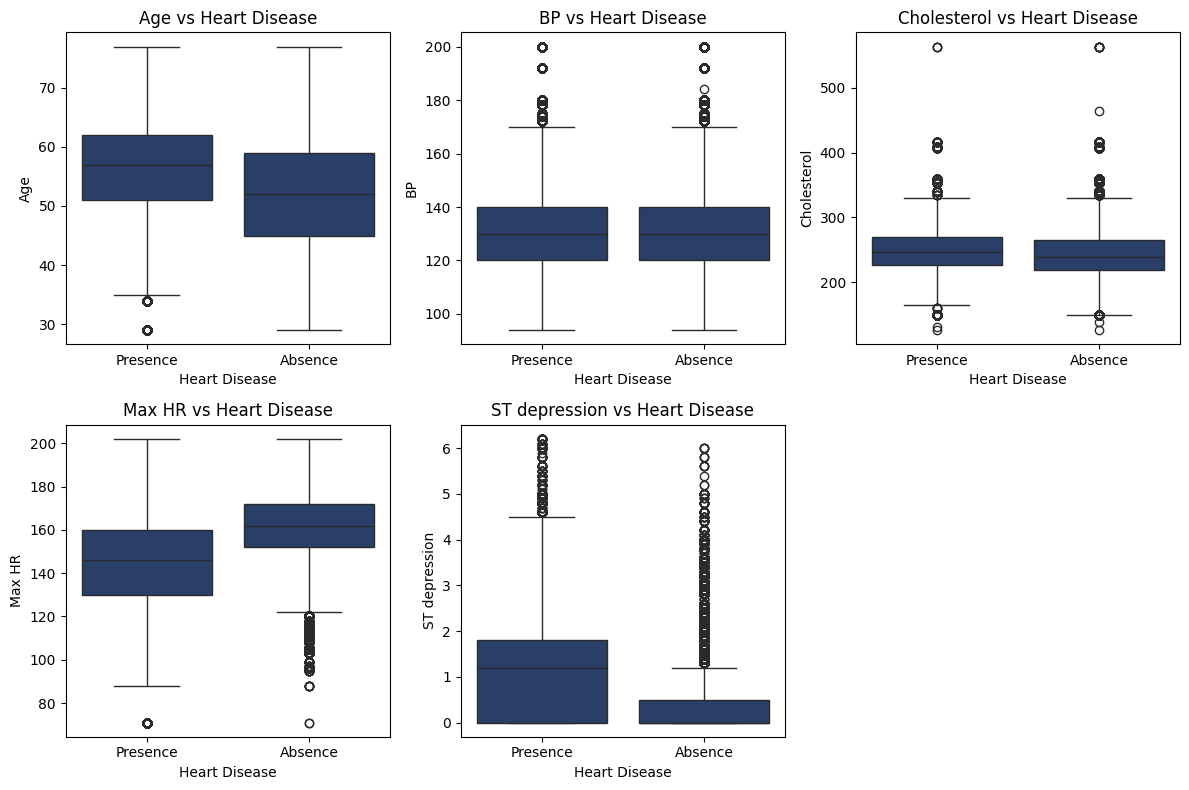

In [17]:
import math

n_cols = 3
n_features = len(numerical_features)
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(
        x=df_train[TARGET],
        y=df_train[col],
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs {TARGET}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### How Categorical Features affect Target

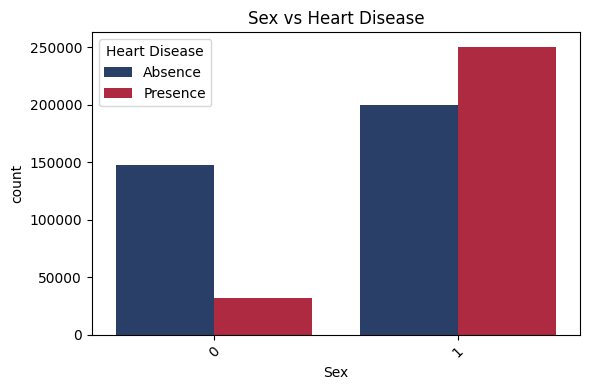

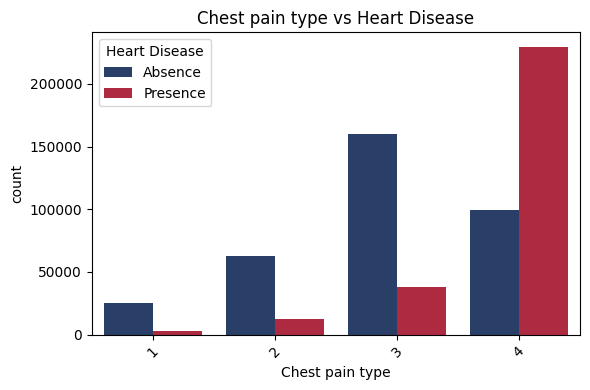

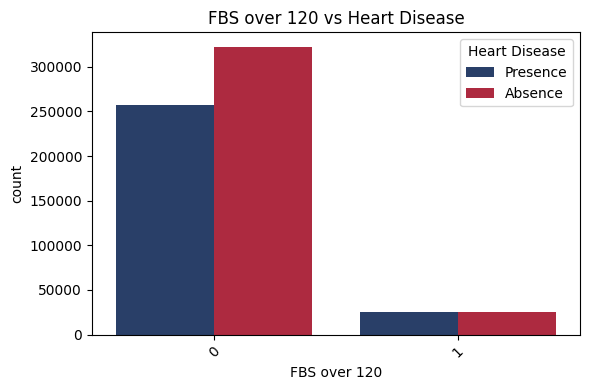

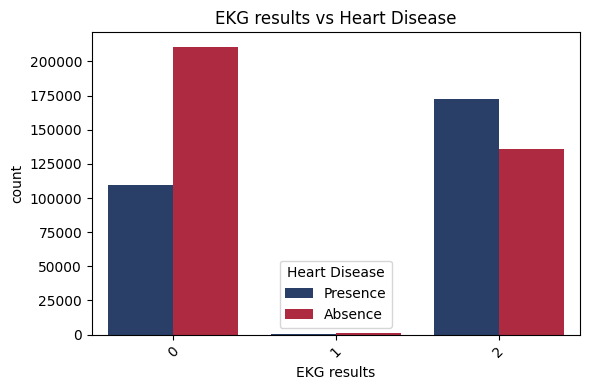

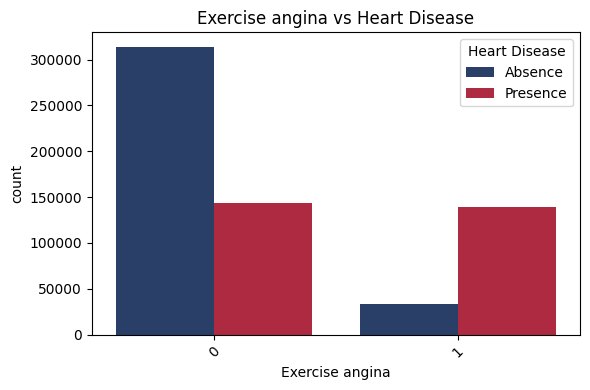

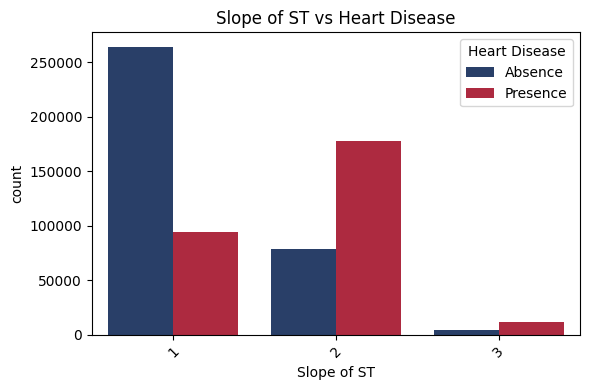

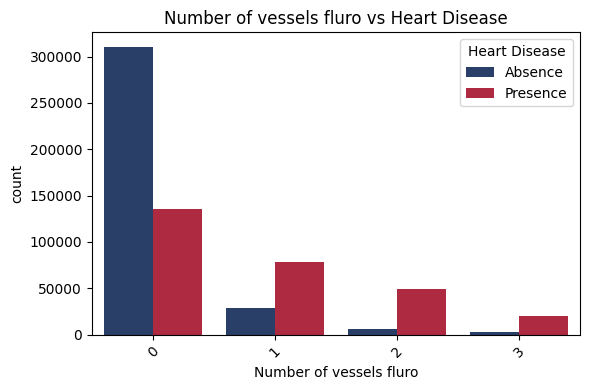

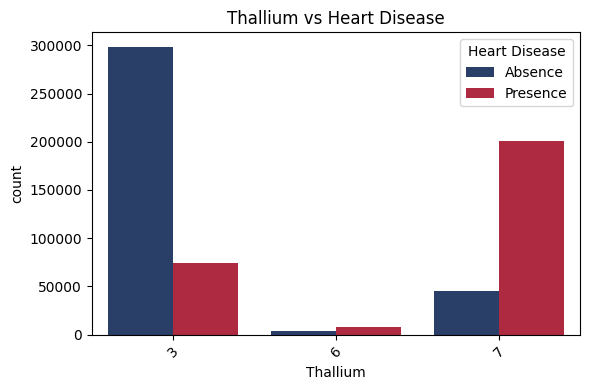

In [18]:
colors = ["#1e3c72", "#c31432"]
for col in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_train, x=col, hue=TARGET, palette=colors)
    plt.title(f'{col} vs {TARGET}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Feature Engineering</b></div>

## Feature Selection

In [ ]:
le = LabelEncoder()
df_train['Heart Disease'] = le.fit_transform(df_train['Heart Disease'])

X = df_train.drop("Heart Disease", axis=1).copy()
y = df_train['Heart Disease'].copy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    random_state=42,
    eval_metric='mlogloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=model_xgb,
    step=1,
    cv=cv,
    scoring='accuracy',
    min_features_to_select=5
)

rfecv.fit(X_train, y_train)

# Plot RFECV performance
plt.figure(figsize=(8, 5))
plt.title("RFECV - Number of Features vs CV Accuracy")
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validated Accuracy")
plt.plot(
    range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
    rfecv.cv_results_['mean_test_score'],
    marker='o'
)
plt.show()

selected_features = X_train.columns[rfecv.support_]
print("Selected Features:")
print(selected_features)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>OPTUNA Fine-Tuning</b></div>

In [ ]:
X = df_train[selected_features]
y = df_train[TARGET]

def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',           # or 'gpu_hist' if GPU enabled
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval   = xgb.DMatrix(X_val, label=y_val)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=2000,
            evals=[(dval, 'validation')],
            early_stopping_rounds=60,
            verbose_eval=False,
            callbacks=[XGBoostPruningCallback(trial, 'validation-auc')]
        )

        preds = model.predict(dval)
        auc_scores.append(roc_auc_score(y_val, preds))

    return np.mean(auc_scores)


study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=50, timeout=3600*1.5)

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Best Model Training & Evaluation</b></div>

In [ ]:
# Final model
best_params = study.best_params
best_params.update({'objective': 'binary:logistic', 'eval_metric': 'auc', 'random_state': 42})

final_tuned_xgb = xgb.XGBClassifier(**best_params)

X_train_selected = X_train[selected_features].copy()
X_val_selected = X_val[selected_features].copy()

# Predict Validation
final_tuned_xgb.fit(X_train_selected, y_train)
y_pred = final_tuned_xgb.predict(X_val_selected)

## Confusion Matrix

In [ ]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='vlag',
    xticklabels=['Absence', 'Presence'],
    yticklabels=['Absence', 'Presence']
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

## Classification Report

In [ ]:
print("\nClassification Report:\n", classification_report(y_val, y_pred))

## ROC Curve

In [ ]:
y_pred_proba = final_tuned_xgb.predict_proba(X_val_selected)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

auc_score = auc(fpr, tpr)
print("Validation AUC score is:", auc_score)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='#c31432', label='Random guess')
plt.plot([0, 0, 1], [0, 1, 1], color='lightgreen', linestyle='--', linewidth=2, label='Perfect model')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for XGBoost model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Calibration Analysis

In [ ]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(12, 5)) 
plt.suptitle('XGB', fontsize=20) 

ax1 = plt.subplot(1, 2, 1)
CalibrationDisplay.from_predictions(y_val, y_pred_proba, n_bins=100, strategy='quantile', ax=ax1)
ax1.set_title('Calibration Curve')

ax2 = plt.subplot(1, 2, 2)
ax2.hist(y_pred_proba, bins=100, edgecolor='black', alpha=0.7)
ax2.set_title('Prediction Distribution (Histogram)')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Test Prediction</b></div>

In [ ]:
# Predict Test
X_test = df_test[selected_features].copy()
y_test_pred = final_tuned_xgb.predict_proba(X_test)[:, 1]

final_pred = pd.DataFrame({
    'id': df_test['id'],
    'Heart Disease': y_test_pred})
final_pred.head()

<div style="
    background: linear-gradient(90deg, #1e3c72, #c31432);
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
<b>Thank you for reading this far !</b><br>
</div>